# Tail Modeling with EVT

While constructing the distribution of assets, instead of using empirical methods, we can use a mixed strategy (**Peak-Over-Threshod**) that models the left tail of standardized residuals (or right tail if we are estimating by loss) with a **General Pareto Distribution (GPD)**. By doing so, we wish to get a more accurate tail estimation and thus construct a more accurate copula model.

In [1]:
import numpy as np
import pandas as pd
import openturns as ot
import pickle
import scipy.stats as stats
from matplotlib import pyplot as plt

import sys
sys.path.append("../src")
from risklib.copula import build_copula_sample
from risklib.plot_utils import plot_QQ

In [2]:
# Load standardized residuals (filtered by GARCH)
roll_garch_vol = pd.read_csv("../outputs/roll_garch_vol.csv", parse_dates=[0], index_col=0)
roll_garch_mean = pd.read_csv("../outputs/roll_garch_mean.csv", parse_dates=[0], index_col=0)
with open("../outputs/roll_garch_res.pkl", 'rb') as f:
    roll_garch_res = pickle.load(f)

T = len(roll_garch_vol)
tickers = roll_garch_vol.columns[:-1]
weights = np.array([0.25, 0.15, 0.20, 0.10, 0.10, 0.10, 0.10])

## POT Methodology

In [3]:
# We use the the first rolling window to demonstrate the methodology
sample_resid = -pd.DataFrame({ticker: roll_garch_res[3000][ticker].std_resid for ticker in tickers})
#sample_resid

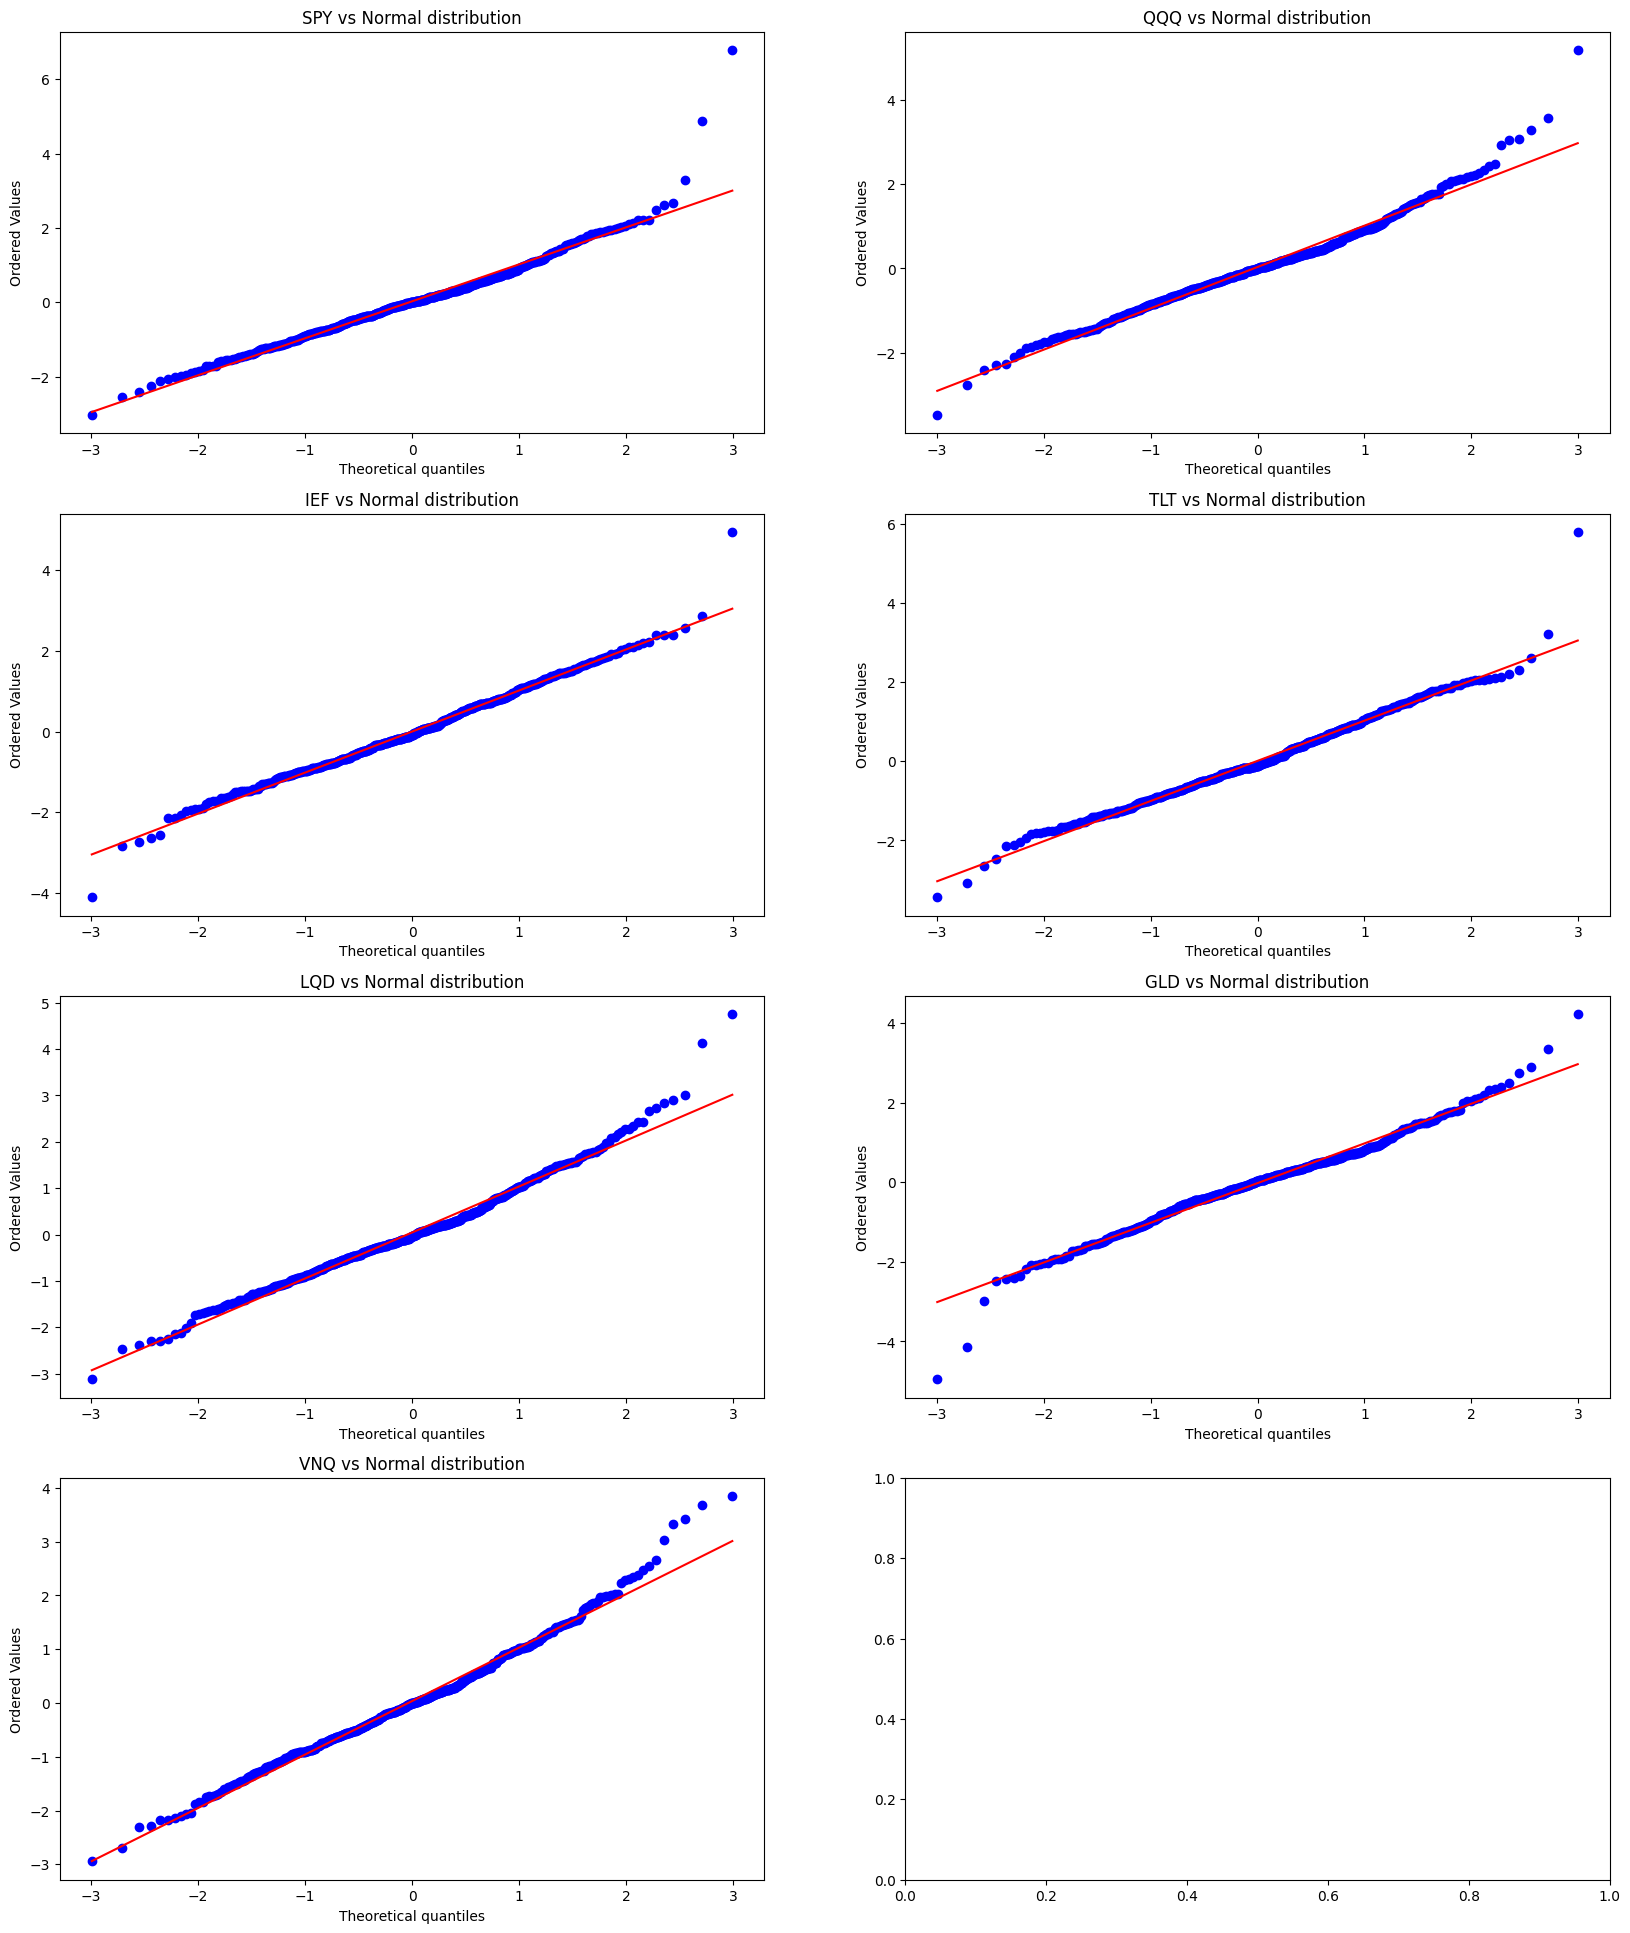

In [4]:
plot_QQ(sample_resid)

### Choose a threshold

To begin with, we need to choose an appropriate threshold so that the excess losses above this level approximately follow a Generalized Pareto Distribution (GPD). We want this threshold to be

1. Stable, which means the estimation results of parameters are not sensitive to small changes in the choice of the threshold.
2. Not too large in case there is not enough points for tail estimation and not too small in case large bulk of data biases the estimation result

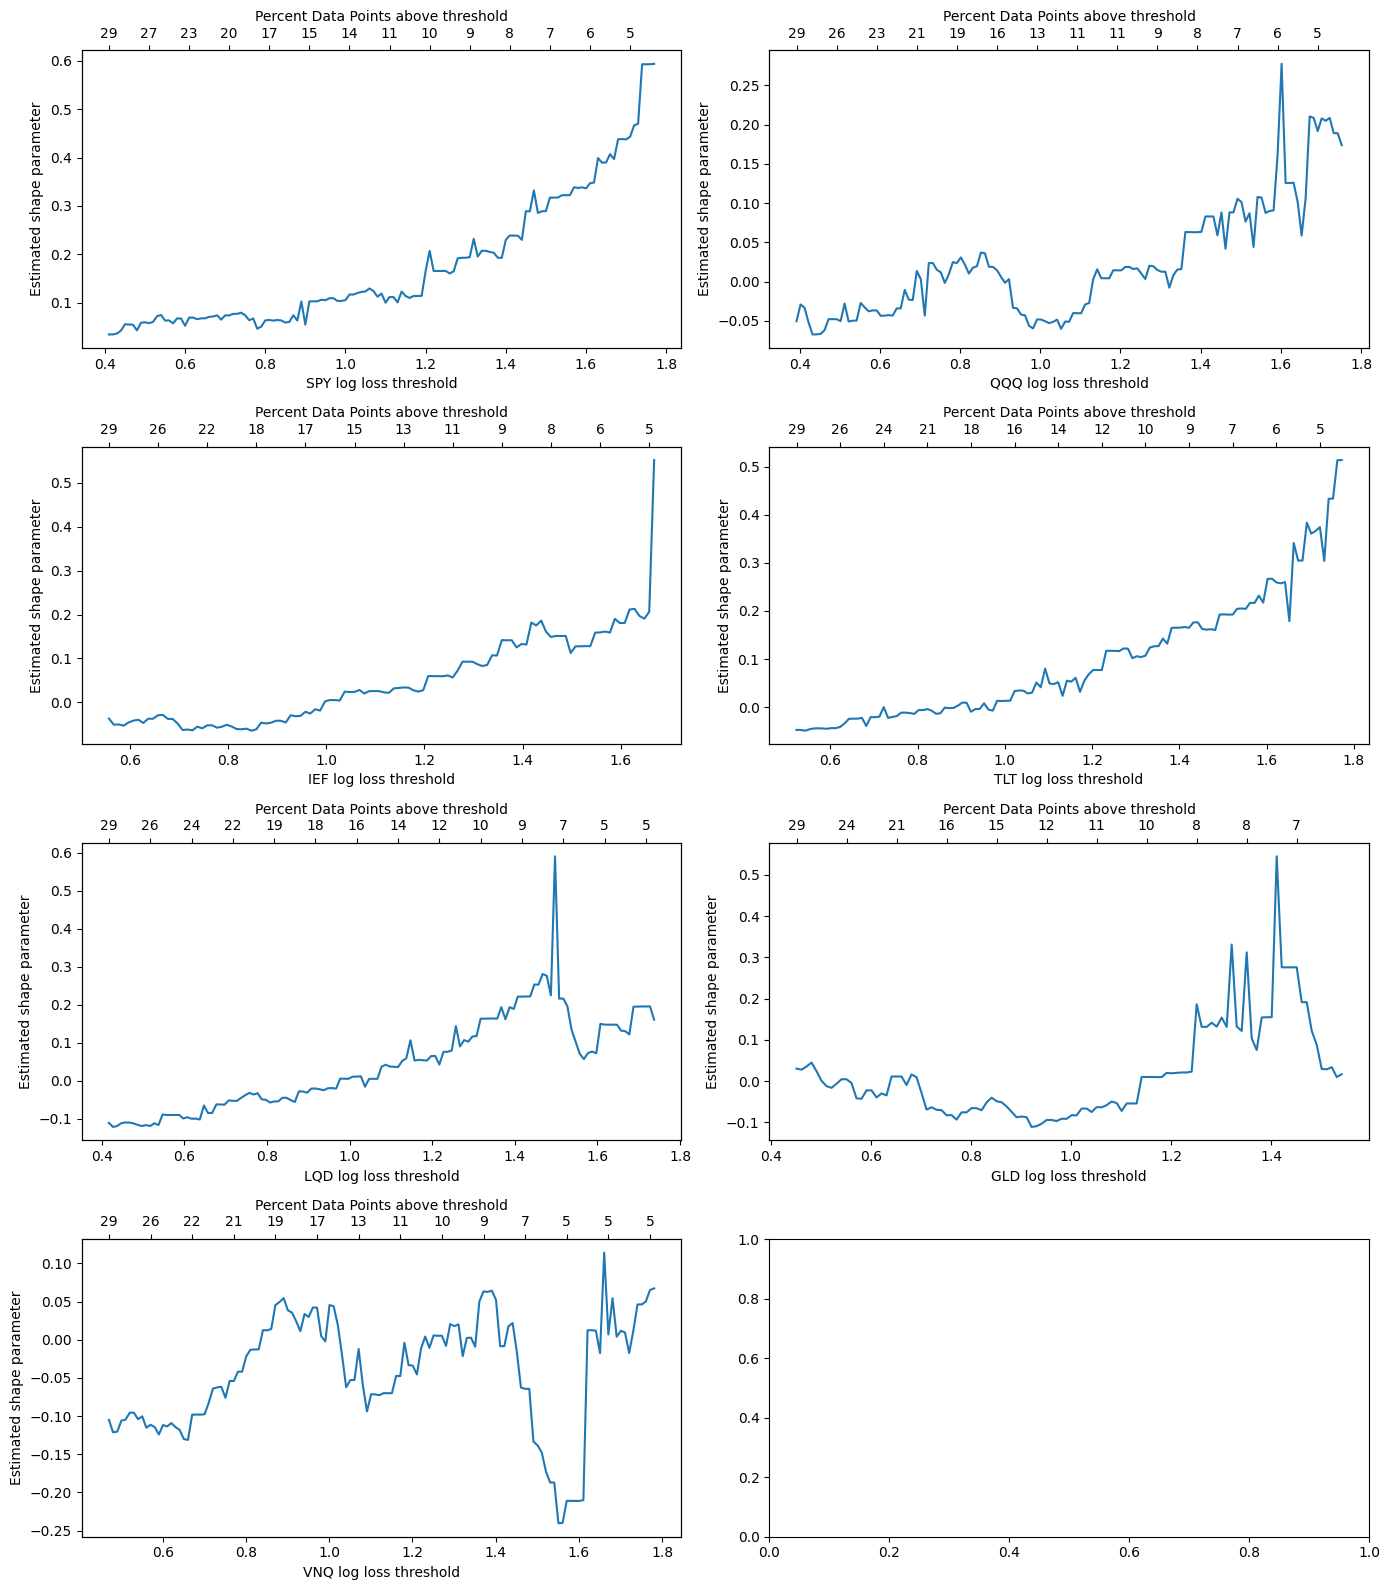

In [5]:
# Plot exstimated shape parameter of GPD vs choice of threshold
def shape_plot_values(data):
    '''Return values that will be used in the plot'''
    data_sort = sorted(data)
    q_low = np.quantile(data_sort, 0.7)            # The lower bound of the set of threshold choices
    q_upper = np.quantile(data_sort, 0.95)
    thres = np.arange(q_low, q_upper, 0.01)    
    shape, ex_thres_per = [], []
    for t in thres:
        excess = data[data > t] - t    
        e_percent = len(excess)/len(data)
        ex_thres_per.append(e_percent)
        # Fit GPD
        xi = stats.genpareto.fit(excess)[0]
        shape.append(xi)
    return thres, shape, ex_thres_per

def plot_shape_stability(log_loss: pd.DataFrame):
    tickers = log_loss.columns
    fig, ax = plt.subplots(4, 2, figsize=(14,16))
    for i, a in enumerate(ax.flat):
        if i >= len(tickers):
            break
        thres, shape, ex_thres_per = shape_plot_values(log_loss[tickers[i]])
        a.plot(thres, shape)
        a_top = a.twiny()
        a_top.set_xlim(a.get_xlim())
        a_top.set_xticks(thres[::10])
        a_top.set_xticklabels([int(100*p) for p in ex_thres_per[::10]])
        a.set_xlabel(f"{tickers[i]} log loss threshold")
        a.set_ylabel("Estimated shape parameter")
        a_top.set_xlabel("Percent Data Points above threshold")
    plt.tight_layout()

plot_shape_stability(sample_resid)

Threshold choice (5~10% exceeding points and locally stable):

We can choose the 0.9 quantile (10% exceeding points) of the filtered loss as the parameter estimates using this threshold is relatively stable across all assets. 

### Threshold choice validation
We can double check our choices by plotting the **Mean Excess Plot**, which should show a relation close to linear at least on the bottom left corner of the plot.

In [6]:
thres_dict = {}
print("Chosen threshold:")
for ticker in tickers:
    thres_dict[ticker] = np.quantile(sample_resid[ticker], 0.9)
    print(f'{ticker} : {thres_dict[ticker]}')

Chosen threshold:
SPY : 1.2731589708084388
QQQ : 1.2601609049566749
IEF : 1.3280311183586444
TLT : 1.3709360264761232
LQD : 1.3836269557616863
GLD : 1.1733564999471047
VNQ : 1.3057992023120244


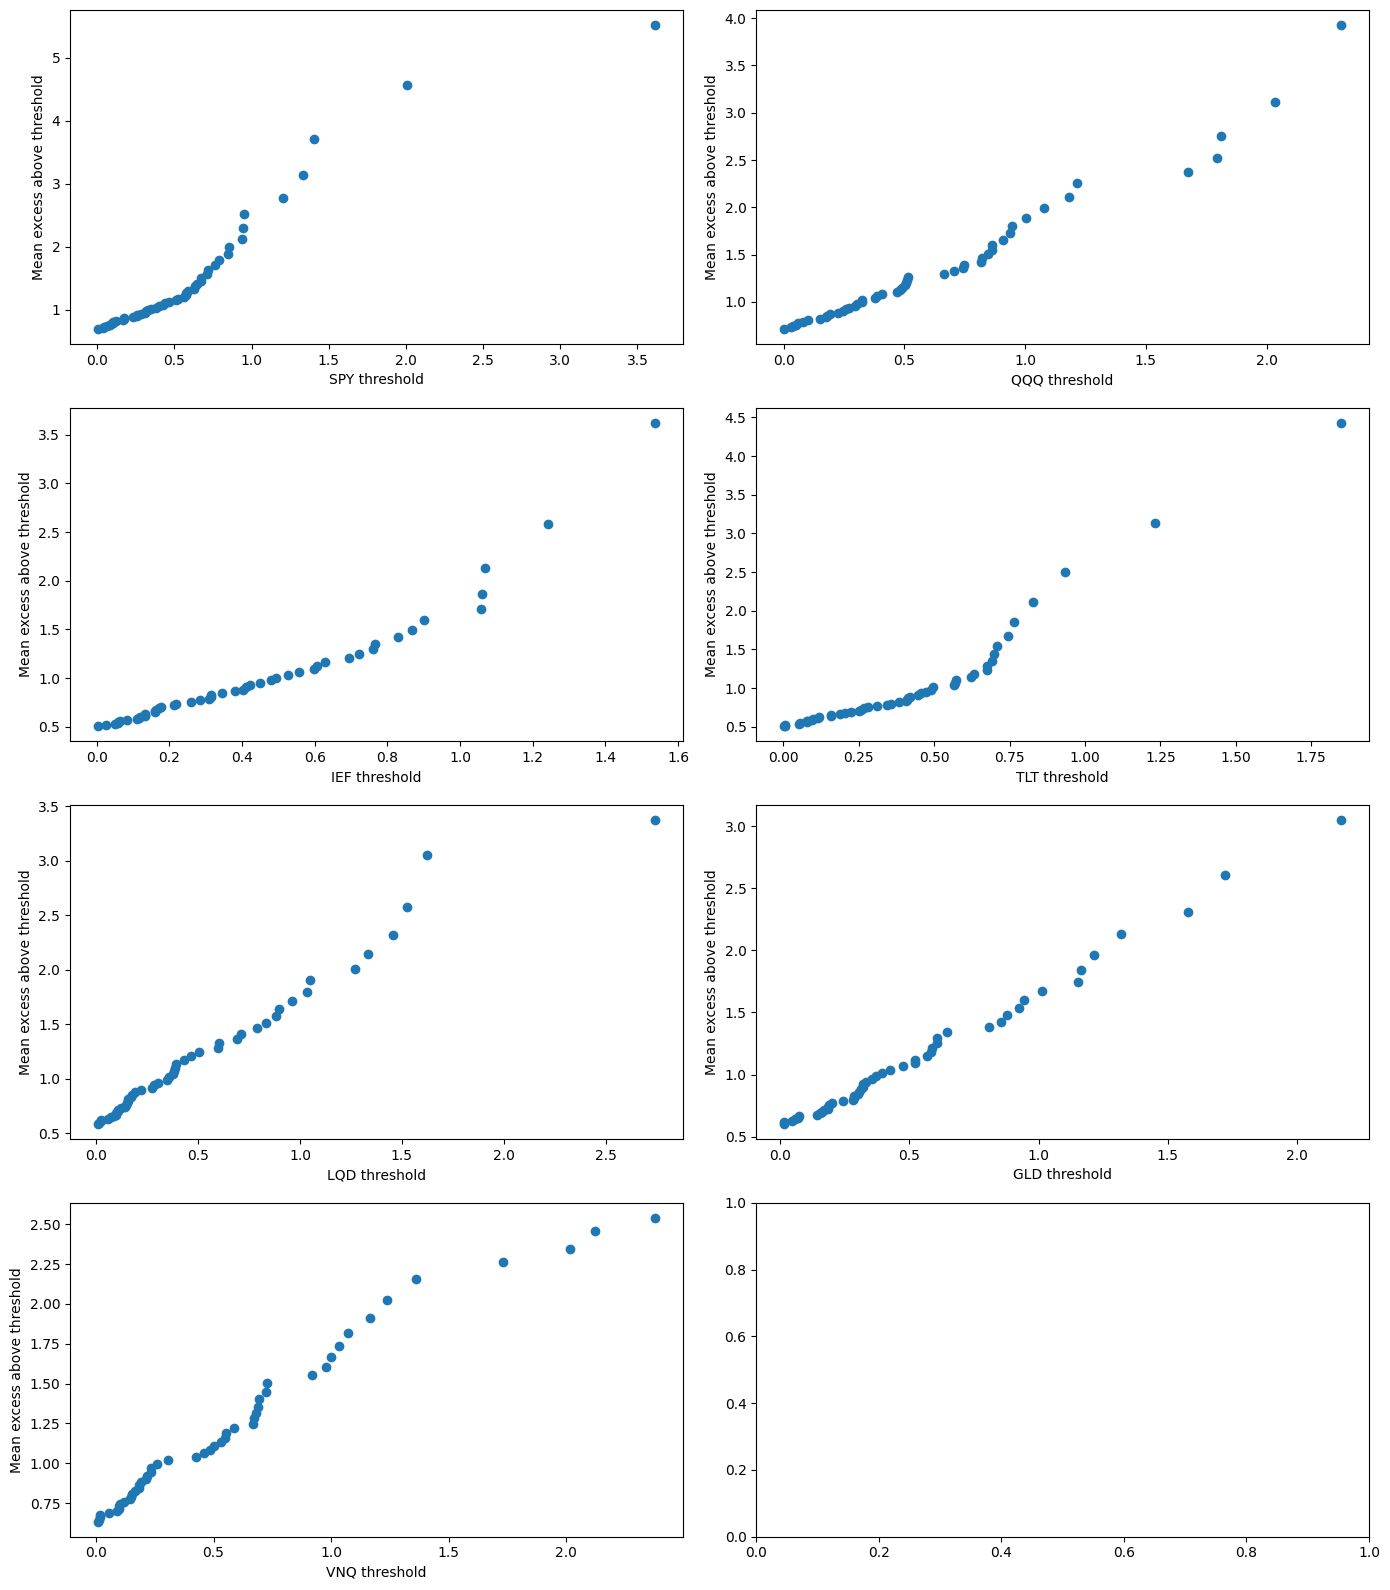

In [7]:
# Mean excess plot
def get_excess(data, thres):
    excess = data[data > thres] - thres
    return sorted(excess)

def get_mean_excess(data, thres):
    mean_excess = []
    excess = get_excess(data, thres)
    for i in range(0, len(excess)-1):
        mean_excess.append(np.mean(excess[i+1:]))
    return mean_excess

def plot_mean_excess(log_loss: pd.DataFrame, thres_dict):
    tickers = log_loss.columns
    fig, ax = plt.subplots(4,2, figsize=(14,16))
    for ticker, a in zip(tickers, ax.flat):
        excess = get_excess(log_loss[ticker], thres_dict[ticker])
        mean_excess = get_mean_excess(log_loss[ticker], thres_dict[ticker])
        a.scatter(excess[:-1], mean_excess)
        a.set_xlabel(f"{ticker} threshold")
        a.set_ylabel("Mean excess above threshold")
    plt.tight_layout()
    
plot_mean_excess(sample_resid, thres_dict)

### Fitting GPD (Generalized Pareto Distribution)

After choosing a threshold, we can start the fitting process. We fit a GPD to the data points exceeding the chosen threshold and use a nonparametric approach to estimate the distribution of the data points below the threshold.

In [8]:
# Fit tails to GPD (thres - x)
def fit_GPD(excess):
    c, loc, s = stats.genpareto.fit(excess, floc=0)
    return c, loc, s

def get_gpd_params(loss_df, thres_dict):
    tickers = loss_df.columns
    gpd_params = {}
    for ticker in tickers:
        data = loss_df[ticker]
        thres = thres_dict[ticker]
        excess = get_excess(data, thres)
        c, loc, s = fit_GPD(excess)
        gpd_params[ticker] = (c, loc, s)
    return gpd_params

gpd_params = get_gpd_params(sample_resid, thres_dict)
print('GPD parameters :')
for ticker in tickers:
    print(f'{ticker} : {gpd_params[ticker]}')

GPD parameters :
SPY : (np.float64(0.15924225911808265), 0, np.float64(0.5687794958669647))
QQQ : (np.float64(0.0005430571669888349), 0, np.float64(0.7021940366191581))
IEF : (np.float64(0.08014435428063037), 0, np.float64(0.4548591570863528))
TLT : (np.float64(0.12834967647688972), 0, np.float64(0.4297755068901809))
LQD : (np.float64(0.16771097547144198), 0, np.float64(0.47861062892589745))
GLD : (np.float64(-0.01761647075641622), 0, np.float64(0.6014665923493638))
VNQ : (np.float64(-0.0007919176200304966), 0, np.float64(0.6232495608540222))


In [9]:
# Define mixed fitted distribution
def evt_cdf(data, samples, thres, nofex, c, s):
    '''Empirical estimate of mixed distribution cdf'''
    n = len(data)
    exp = nofex/n
    ecdf = stats.ecdf(data).cdf
    res = []
    for sample in samples:
        if sample < thres:
            p = ecdf.evaluate(sample)
            p = min(max(p,1e-10), 1-1e-10)
            res.append(float(p))
        else:
            base = 1 + c*(sample-thres)/s
            p = 1 - exp * np.exp((1/c) * np.log(base))
            p = min(max(p,1e-10), 1-1e-10)
            res.append(p)
    return res

def evt_inv_cdf(data, probs, thres, nofex, c, s):
    '''Empirical estimate of mixed distribution quantile'''
    n = len(data)
    exp = nofex/n
    res = []
    for p in probs:
        if p <= 1-exp:
            res.append(np.quantile(data, p, method='inverted_cdf'))
        else:
            res.append(thres + (s/c)*(((1-p)/exp)**(-c) - 1))
    return res

def get_samples_fitted(size, thres, nofex, c, s, data):
    '''Draw samples from the fitted mixed distribution'''
    U = np.random.uniform(0,1,size=size)
    return evt_inv_cdf(data, U, thres, nofex, c, s)

### Estimation validation

We can use a QQ plot comparing samples drawn from the fitted distribution and the loss residuals to check the goodness of fit.

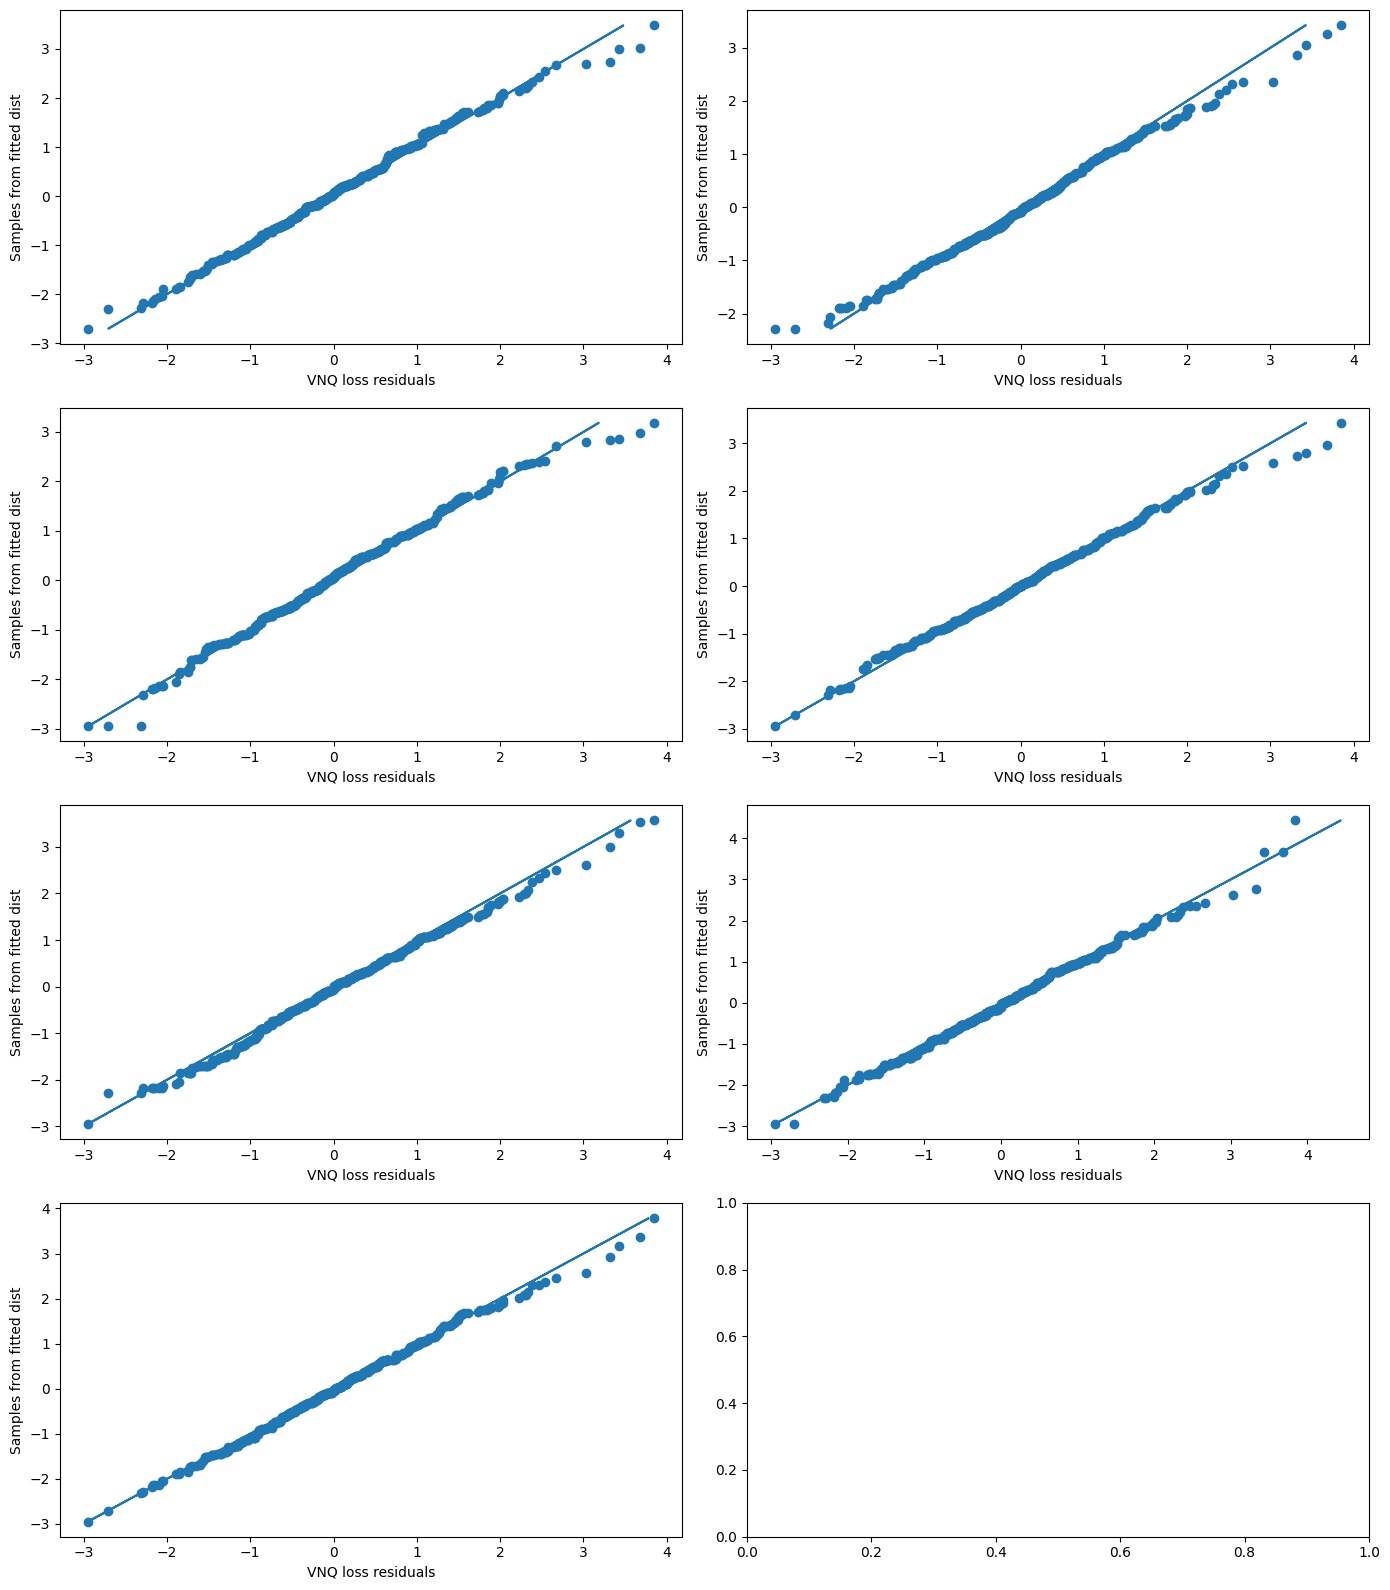

In [10]:
# Test fitted distribtution

# rng = np.random.default_rng(134)        # For reproducing results
# U = rng.random.uniform(0,1,size=3894)

def plot_QQ_fitted(loss_df: pd.DataFrame, thres_dict, gpd_params):
    '''Plot empirical QQ plots of all log_loss data vs the fitted distribution'''
    tickers = loss_df.columns
    fig, ax = plt.subplots(4,2, figsize=(14,16))
    for tickers, a in zip(tickers, ax.flat):
        data = loss_df[ticker]
        excess = get_excess(data, thres_dict[ticker])
        param = gpd_params[ticker]
        c, s = param[0], param[2]
        x = get_samples_fitted(len(data), thres_dict[ticker], len(excess), c, s, data)
        a.scatter(sorted(data), sorted(x))
        a.plot(x,x)
        a.set_xlabel(f"{ticker} loss residuals")
        a.set_ylabel("Samples from fitted dist")
    plt.tight_layout()


plot_QQ_fitted(sample_resid, thres_dict, gpd_params)

## VaR/ES Monte Carlo Estimation with Copulas

Now that we know how to estimate the distribution using EVT, we can try to employ it with copula construction and estimate the VaR/ES with Monte Carlo simulation.

For rolling estimation, we choose the threshold to to be the 0.9 quantile of the window to avoid manual selection.

In [11]:
def get_var_es_evt_copula(garch_res, tickers, vol, mean, copula, weights, q):
    ''' Estimate portfolio VaR/ES using Monte Carlo methods with samples drawn from fitted copula
    '''
    resid_df = -pd.DataFrame({ticker: garch_res[ticker].std_resid for ticker in tickers})
    # Set threshold
    thres_dict = {}
    for ticker in tickers:
        thres_dict[ticker] = np.quantile(resid_df[ticker], 0.9)

    # Fit GPD
    gpd_params = get_gpd_params(resid_df, thres_dict)
    
    # CDF transform
    resid_cdf = {}
    for ticker in tickers:
        data = resid_df[ticker]
        thres = thres_dict[ticker]
        nofex = len(get_excess(data, thres))
        c, s = gpd_params[ticker][0], gpd_params[ticker][2]
        resid_cdf[ticker] = evt_cdf(data, data, thres, nofex, c, s)
    resid_cdf = pd.DataFrame(resid_cdf)
    
    # Build copula with transformed residuals and sample from it
    samples = build_copula_sample(resid_cdf, copula=copula, sample_size=10000)
    samples.columns = tickers
    
    # Inverse CDF transform samples
    resid_samples = {}
    for ticker in tickers:
        data = resid_df[ticker]
        probs = samples[ticker]
        thres = thres_dict[ticker]
        nofex = len(get_excess(data, thres))
        c, s = gpd_params[ticker][0], gpd_params[ticker][2]
        resid_samples[ticker] = evt_inv_cdf(data, probs, thres, nofex, c, s)
    resid_samples = pd.DataFrame(resid_samples)

    port_var, port_es = [], []
    for i in range(len(vol)):
        # Transform std residual samples back to loss
        loss_samples = resid_samples * vol.iloc[i] + (-mean.iloc[i])
        # Calculate simulated portfolio returns
        port_loss_samples = loss_samples @ weights
        # Estimated VaR
        var = np.quantile(port_loss_samples, q)
        es = port_loss_samples[port_loss_samples > var].mean()
        port_var.append(var)
        port_es.append(es)
    return port_var, port_es


def roll_var_es_evt_copula(roll_garch_res, tickers, roll_garch_vol, roll_garch_mean, copula, weights, window=504, step=21, q=0.99):
    T = len(roll_garch_vol)
    roll_var, roll_es = np.full((T,), np.nan), np.full((T,), np.nan)
    for i in range(window, T, step):
        n = min(step,T-i)
        var, es = get_var_es_evt_copula(
            roll_garch_res[i],
            tickers,
            roll_garch_vol.iloc[i:i+n],
            roll_garch_mean.iloc[i:i+n],
            copula=copula,
            weights=weights,
            q=q,
        )
        for j in range(n):
            roll_var[i+j], roll_es[i+j] = var[j], es[j]
        if (i-window) % (10*step) == 0:
            print(f'window {i-window} portfolio VaR/ES estimation complete')
    roll_var = pd.DataFrame(roll_var, index=roll_garch_mean.index, columns=[f'port_var{int(100*q)}'])
    roll_es = pd.DataFrame(roll_es, index=roll_garch_mean.index, columns=[f'port_es{int(100*q)}'])
    return roll_var, roll_es

port_var99_EVT_Copula, port_es99_EVT_Copula = roll_var_es_evt_copula(
    roll_garch_res, tickers, roll_garch_vol[tickers], roll_garch_mean[tickers], copula='studentT', weights=weights, window=504, step=21, q=0.99
)
port_var95_EVT_Copula, port_es95_EVT_Copula = roll_var_es_evt_copula(
    roll_garch_res, tickers, roll_garch_vol[tickers], roll_garch_mean[tickers], copula='studentT', weights=weights, window=504, step=21, q=0.95
)

window 0 portfolio VaR/ES estimation complete
window 210 portfolio VaR/ES estimation complete
window 420 portfolio VaR/ES estimation complete
window 630 portfolio VaR/ES estimation complete
window 840 portfolio VaR/ES estimation complete
window 1050 portfolio VaR/ES estimation complete
window 1260 portfolio VaR/ES estimation complete
window 1470 portfolio VaR/ES estimation complete
window 1680 portfolio VaR/ES estimation complete
window 1890 portfolio VaR/ES estimation complete
window 2100 portfolio VaR/ES estimation complete
window 2310 portfolio VaR/ES estimation complete
window 2520 portfolio VaR/ES estimation complete
window 2730 portfolio VaR/ES estimation complete
window 2940 portfolio VaR/ES estimation complete
window 3150 portfolio VaR/ES estimation complete
window 3360 portfolio VaR/ES estimation complete
window 3570 portfolio VaR/ES estimation complete
window 3780 portfolio VaR/ES estimation complete
window 3990 portfolio VaR/ES estimation complete
window 4200 portfolio VaR/E

In [12]:
port_var99_EVT_Copula.to_csv('../outputs/port_var99_EVT_Copula.csv', index=True)
port_es99_EVT_Copula.to_csv('../outputs/port_es99_EVT_Copula.csv', index=True)
port_var95_EVT_Copula.to_csv('../outputs/port_var95_EVT_Copula.csv', index=True)
port_es95_EVT_Copula.to_csv('../outputs/port_es95_EVT_Copula.csv', index=True)